# 05. Human-in-the-Loop (HITL) Approaches

## 📚 Learning Objectives

By completing this notebook, you will:
- Design human-in-the-loop (HITL) workflows
- Balance automation and human oversight
- Implement and evaluate HITL patterns

## 🔗 Prerequisites

- ✅ Basic Python
- ✅ Basic NumPy/Pandas (when applicable)

---

---

# 05. Human-in-the-Loop (HITL) Approaches

## 🚨 THE PROBLEM: We Need Human Oversight

**Remember the limitation from the previous notebook?**

We learned accountability frameworks for defining responsibilities. But we discovered:

**How do we incorporate human judgment into AI decision-making?**

**The Problem**: Ethical AI systems also need:
- ❌ **Human oversight** (human judgment for critical decisions)
- ❌ **Human-in-the-loop** (HITL) approaches
- ❌ **Human review** for uncertain cases
- ❌ **Human validation** of AI decisions

**We've learned:**
- ✅ How to use SHAP, LIME, and counterfactuals (Notebooks 1-3)
- ✅ How to establish accountability frameworks (Notebook 4)
- ✅ Explanation methods and accountability

**But we haven't learned:**
- ❌ How to **incorporate human judgment** into AI decisions
- ❌ How to implement **human-in-the-loop** approaches
- ❌ How to enable **human review** for uncertain cases
- ❌ How to **combine AI with human judgment**

**We need human-in-the-loop approaches** to:
1. Incorporate human judgment into AI decisions
2. Enable human review for uncertain cases
3. Provide human oversight for critical decisions
4. Combine AI efficiency with human judgment

**This notebook solves that problem** by teaching you human-in-the-loop approaches for ethical AI!

---

## 📚 Prerequisites (What You Need First)

**BEFORE starting this notebook**, you should have completed:
- ✅ **Example 1: SHAP Explanations** - Understanding explainability
- ✅ **Example 2: LIME Explanations** - Understanding local explanations
- ✅ **Example 3: Counterfactual Analysis** - Understanding "what if" scenarios
- ✅ **Example 4: Accountability Frameworks** - Understanding accountability
- ✅ **Basic Python knowledge**: Functions, data manipulation

**If you haven't completed these**, you might struggle with:
- Understanding why human oversight matters
- Knowing how to implement HITL approaches
- Understanding human-AI collaboration

---

## 🔗 Where This Notebook Fits

**This is the FIFTH example in Unit 4** - it teaches you human oversight!

**Why this example FIFTH?**
- **Before** you can implement HITL, you need explainability (Examples 1-3)
- **Before** you can implement HITL, you need accountability (Example 4)
- **Before** you can build transparent systems, you need human oversight

**Builds on**: 
- 📓 Example 1: SHAP Explanations (explainability)
- 📓 Example 2: LIME Explanations (local explanations)
- 📓 Example 3: Counterfactual Analysis ("what if" scenarios)
- 📓 Example 4: Accountability Frameworks (accountability)

**Leads to**: 
- 📓 Example 6: Transparency Tools (transparency frameworks)

**Why this order?**
1. HITL provides **human oversight** (needed for ethical AI)
2. HITL teaches **human-AI collaboration** (critical for trust)
3. HITL shows **uncertainty handling** (essential for transparency)

---

## The Story: Combining AI with Human Judgment

Imagine you're a doctor using AI to diagnose patients. **Before** HITL, AI would make all decisions automatically (risky!). **After** implementing HITL, uncertain cases get human review - combining AI efficiency with human judgment!

Same with AI: **Before** we have automated decisions but no human oversight, now we learn HITL - incorporate human judgment for uncertain cases! **After** HITL, we have AI systems with human oversight!

---

## Why HITL Approaches Matter

Human-in-the-loop approaches are essential for ethical AI:
- **Human Judgment**: Incorporate human expertise into AI decisions
- **Oversight**: Provide human oversight for critical decisions
- **Trust**: Build user confidence through human involvement
- **Safety**: Reduce risks through human validation
- **Ethics**: Ensure ethical decisions through human judgment

## Learning Objectives
1. Understand human-in-the-loop approaches
2. Learn how to identify uncertain cases
3. Implement human review mechanisms
4. Combine AI predictions with human judgment
5. Evaluate HITL effectiveness
6. Design HITL workflows

## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

## Part 1: Confidence-Based Routing - HITL You Can Run

The core HITL mechanism: the model handles cases it is confident about, and **defers the
uncertain ones to a human**. We implement it with a probability threshold and measure what
it buys us. (Unit 2's fair-development notebook previewed this idea; here we build the
routing itself and study the threshold trade-off.)

HITL ROUTING AT DIFFERENT CONFIDENCE THRESHOLDS
 threshold  automated_share  auto_accuracy  deferred_share  deferred_model_accuracy
       0.6            0.919          0.917           0.081                    0.562
       0.7            0.830          0.949           0.170                    0.588
       0.8            0.731          0.967           0.269                    0.674
       0.9            0.620          0.984           0.380                    0.731

Fully-automated accuracy (no HITL): 0.888
Pattern: raising the threshold sends MORE cases to humans, and the
automated remainder gets MORE reliable - staffing cost vs error cost.


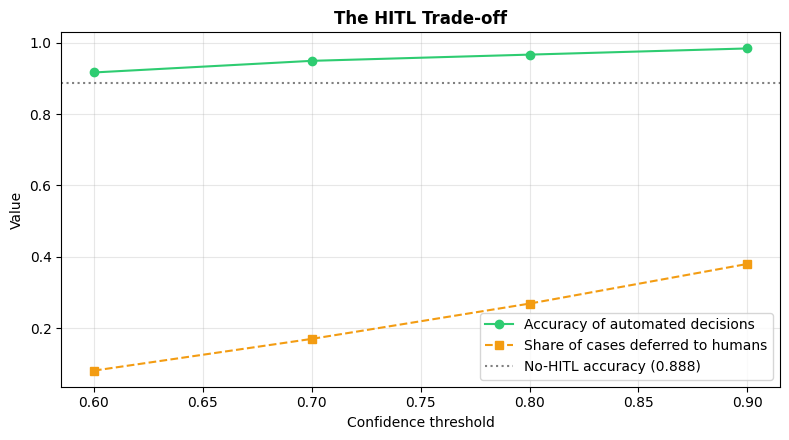


Design checklist for real HITL systems (what we just demonstrated + policy):
  1. Defer on LOW CONFIDENCE (implemented above)
  2. Defer on HIGH STAKES regardless of confidence (policy rule)
  3. Log reviewer + outcome in the audit trail (Notebook 04)
  4. Feed human corrections back into training data


In [1]:
# Step 2: Implement confidence-based human-in-the-loop routing
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

np.random.seed(42)
n = 3000
X = pd.DataFrame({
    'income':         np.random.normal(55, 18, n).clip(10, 150),
    'debt_ratio':     np.random.uniform(0.05, 0.6, n),
    'years_employed': np.random.randint(0, 25, n),
    'credit_history': np.random.normal(650, 80, n).clip(350, 850),
})
score = (0.03*(X['income']-55) - 4.0*(X['debt_ratio']-0.3)
         + 0.05*X['years_employed'] + 0.008*(X['credit_history']-650))
y = (score + np.random.normal(0, 0.35, n) > 0).astype(int)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,
                                                    random_state=42, stratify=y)
model = RandomForestClassifier(n_estimators=150, random_state=42)
model.fit(X_train, y_train)

proba = model.predict_proba(X_test)
confidence = proba.max(axis=1)
pred = model.predict(X_test)

def hitl_route(threshold):
    """Split decisions into automated vs human-review at a confidence threshold."""
    auto = confidence >= threshold
    return {
        'threshold': threshold,
        'automated_share': auto.mean(),
        'auto_accuracy': accuracy_score(y_test[auto], pred[auto]) if auto.any() else np.nan,
        'deferred_share': (~auto).mean(),
        'deferred_model_accuracy': (accuracy_score(y_test[~auto], pred[~auto])
                                    if (~auto).any() else np.nan),
    }

print("HITL ROUTING AT DIFFERENT CONFIDENCE THRESHOLDS")
print("=" * 80)
rows = [hitl_route(t) for t in [0.6, 0.7, 0.8, 0.9]]
table = pd.DataFrame(rows)
print(table.round(3).to_string(index=False))
overall = accuracy_score(y_test, pred)
print(f"\nFully-automated accuracy (no HITL): {overall:.3f}")
print("Pattern: raising the threshold sends MORE cases to humans, and the")
print("automated remainder gets MORE reliable - staffing cost vs error cost.")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(table['threshold'], table['auto_accuracy'], 'o-', color='#2ecc71',
        label='Accuracy of automated decisions')
ax.plot(table['threshold'], table['deferred_share'], 's--', color='#f39c12',
        label='Share of cases deferred to humans')
ax.axhline(overall, color='gray', linestyle=':', label=f'No-HITL accuracy ({overall:.3f})')
ax.set_xlabel('Confidence threshold'); ax.set_ylabel('Value')
ax.set_title('The HITL Trade-off', fontsize=12, fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\nDesign checklist for real HITL systems (what we just demonstrated + policy):")
print("  1. Defer on LOW CONFIDENCE (implemented above)")
print("  2. Defer on HIGH STAKES regardless of confidence (policy rule)")
print("  3. Log reviewer + outcome in the audit trail (Notebook 04)")
print("  4. Feed human corrections back into training data")


---

## 🚫 When HITL Approaches Hit a Limitation

### The Limitation We Discovered

We've learned human-in-the-loop approaches for incorporating human judgment. **But there's still a challenge:**

**How do we integrate all transparency tools into a comprehensive framework?**

HITL approaches work well when:
- ✅ We can identify uncertain cases
- ✅ We can incorporate human judgment
- ✅ We have human oversight mechanisms

**But comprehensive transparency also needs:**
- ❌ **Integrated transparency tools** (combine all explanation methods)
- ❌ **Transparency frameworks** (systematic approach to transparency)
- ❌ **Tool comparison** (choose the right tool for each situation)
- ❌ **Complete transparency solutions** (end-to-end transparency)

### Why This Is a Problem

When we have individual tools but no framework:
- We may not know which tool to use when
- We may not integrate tools effectively
- We may not have a systematic transparency approach
- We may miss important transparency aspects

### The Solution: Transparency Tools and Frameworks

We need **transparency tools and frameworks** to:
1. Compare and integrate different explanation methods
2. Create comprehensive transparency frameworks
3. Choose the right tool for each situation
4. Build complete transparency solutions

**This is exactly what we'll learn in the next notebook: Transparency Tools!**

---

## ➡️ Next Steps

**You've completed this notebook!** Now you understand:
- ✅ How to use SHAP, LIME, and counterfactuals (Notebooks 1-3)
- ✅ How to establish accountability (Notebook 4)
- ✅ How to implement HITL (This notebook!)
- ✅ **The limitation**: We need comprehensive transparency frameworks!

**Next notebook**: `06_transparency_tools.ipynb`
- Learn about transparency tools comparison
- Understand transparency frameworks
- Integrate all explanation methods
- Build comprehensive transparency solutions